In [1]:
import sys
from pathlib import Path
import numpy as np
from typing import Callable, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats
import itertools
from abc import ABC, abstractmethod

In [2]:
# Ручная реализация AdaGrad
def adagrad(
    obj: Callable[[np.ndarray], np.float64],
    grad: Callable[[np.ndarray], np.ndarray],
    x0: np.ndarray,
    lr: np.float64 = 1e-2,
    eps: np.float64 = 1e-8,
    tolerance: np.float64 = 1e-6,
    max_iter: int = 1000
) -> list[np.ndarray]:
    
    x = x0.astype(np.float64).copy()
    history = [x.copy()]
    # Кумулятивный исорический градиент (квадраты градиентов)
    G = np.zeros_like(x, dtype=np.float64)
    for k in range(max_iter):
        grad_x = grad(x)
        if np.linalg.norm(grad_x) < tolerance:
            break
        # Аккумулируем квадраты текущего градиента
        G += grad_x ** 2
        # адаптивный шаг покоординатно
        x -= (lr / (np.sqrt(G) + eps)) * grad_x
        history.append(x.copy())
    return history

In [3]:
# Ручная реализация AdamW
def adamw(
    obj: Callable[[np.ndarray], np.float64],
    grad: Callable[[np.ndarray], np.ndarray],
    x0: np.ndarray,
    lr: np.float64 = 1e-3,
    beta1: np.float64 = 0.9,
    beta2: np.float64 = 0.999,
    eps: np.float64 = 1e-8,
    weight_decay: np.float64 = 1e-2,
    tolerance: np.float64 = 1e-6,
    max_iter: int = 1000
) -> list[np.ndarray]:

    x = x0.astype(np.float64).copy()
    history = [x.copy()]
    # первый (m) и второй (v) моменты
    m = np.zeros_like(x, dtype=np.float64)
    v = np.zeros_like(x, dtype=np.float64)
    for k in range(1, max_iter + 1):
        grad_x = grad(x)
        if np.linalg.norm(grad_x) < tolerance:
            break
        # Обновление моментов (экспоненциальное сглаживание)
        m = beta1 * m + (1.0 - beta1) * grad_x
        v = beta2 * v + (1.0 - beta2) * (grad_x ** 2)
        # Коррекция смещения (bias correction) для первых итераций
        m_hat = m / (1.0 - beta1 ** k)
        v_hat = v / (1.0 - beta2 ** k)
        # обновление весов с изолированным затуханием (Decoupled Weight Decay)
        # (В отличие от Adam, регуляризация применяется в обход векторов m и v)
        x -= lr * weight_decay * x + (lr / (np.sqrt(v_hat) + eps)) * m_hat
        history.append(x.copy())
    return history

# Онлайн обучение. Постановка задачи


На каждом шаге $t = 1, 2, \dots$:
1) Алгоритм выбирает вектор весов $w_t \in \mathbb{R}^d$.
2) "Природа" выдает объект признаков $X_t$ и истинный таргет $y_t$, формируя локальную функцию потерь $\mathcal{L}_t(w)$. Для линейной регрессии: $\mathcal{L}_t(w) = \frac{1}{2} (X_t w - y_t)^2$.
3) Алгоритм несет потери $\mathcal{L}_t(w_t)$ и вычисляет стохастический градиент(где $B$ - размер батча на шаге $t$):
$$g_t = \nabla \mathcal{L}_t(w_t) = \frac{1}{B} X_t^\top (X_t w_t - y_t)$$
4) Цель оптимизатора - выбрать последовательность $\{w_t\}$, минимизирующую регрет за $T$ шагов относительно наилучшего статического вектора весов $w^*$:$$R_T = \sum_{t=1}^T \mathcal{L}_t(w_t) - \min_{w^*} \sum_{t=1}^T \mathcal{L}_t(w^*)$$

## AdaGrad
Адаптирует скорость обучения индивидуально для каждого признака (координаты вектора весов) на основе исторической изменчивости градиента.
На шаге $t$ для каждой координаты $i \in \{1, \dots, d\}$ аккумулируется сумма квадратов всех прошлых градиентов:
$$G_{t, i} = G_{t-1, i} + g_{t, i}^2$$
В векторной форме через покоординатное умножение $\odot$:
$$G_t = G_{t-1} + g_t \odot g_t$$
Правило обновления весов:$$w_{t+1} = w_t - \frac{\eta}{\sqrt{G_t} + \epsilon} \odot g_t$$
Где $\eta$ - базовый learning rate, а $\epsilon > 0$ - параметр сглаживания, предотвращающий деление на ноль.

- AdaGrad гарантирует верхнюю границу регрета порядка $\mathcal{O}(\sqrt{T})$. Если градиенты по какой-то координате близки к нулю (редкий признак), то $G_{t,i}$ почти не растет, и при редком появлении этого признака модель делает по нему крупный, значимый шаг.
- Минус: функция $G_{t,i}$ монотонно возрастает. При $t \to \infty$ знаменатель $\sqrt{G_{t,i}} \to \infty$, что приводит к $\eta_{eff} \to 0$. В бесконечном потоке данных AdaGrad полностью "замораживает" веса и теряет способность адаптироваться.

## AdamW
Заменяет бесконечную память AdaGrad на экспоненциально затухающее скользящее среднее и изолирует регуляризацию от адаптивного шага. 
Оценка первого момента (инерция / momentum):$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
Оценка второго несмещенного момента (адаптивный масштаб):$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t \odot g_t$$
Коррекция смещения (Bias Correction): Поскольку $m_0 = 0$ и $v_0 = 0$, в начале потока значения занижены. 
Их нормируют:$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
Шаг обновления весов с разделенным затуханием (Decoupled Weight Decay), где $\lambda$ - коэффициент затухания весов:$$w_{t+1} = w_t - \eta \lambda w_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t$$

- Concept Drift: благодаря коэффициентам $\beta_1, \beta_2 \in (0, 1)$ алгоритм "помнит" только фиксированное окно истории (для $\beta_2 = 0.999$ это примерно последние 1000 батчей). Если природа данных изменилась, старые квадраты градиентов затухают, позволяя весам динамически перестраиваться под новый ландшафт потерь.
- Корректная регуляризация: в Adam штраф $\lambda w_t$ добавлялся бы в $g_t$, проходя через знаменатель $\sqrt{v_t}$. В онлайн-потоке это приводило бы к тому, что часто обновляемые признаки штрафовались бы слабее, чем редко обновляемые. AdamW гарантирует равномерное затухание сложности модели по всем координатам за счет вынесения члена $-\eta \lambda w_t$ наружу.

## FTRL (FoReL, Follow the Regularized Leader)
В отличие от SGD, который делает шаг от текущей точки $w_t$ на основе текущего градиента $g_t$, FTRL на каждом шаге $t$ заново решает глобальную задачу оптимизации для определения весов на следующий шаг $w_{t+1}$.
Алгоритм ищет такой вектор весов, который минимизирует сумму всех ранее полученных линейных приближений функций потерь с учетом регуляризатора 
$\Psi(w)$ 
(где $g_s \in \mathbb{R}^d$ - вектор градиента, полученный на шаге $s$; 
$\langle g_s, w \rangle$ - скалярное произведение, задающее линейную аппроксимацию потерь;
$\Psi(w)$ - функция регуляризации, обычно выбирается комбинация $L_1$ и $L_2$: $\Psi(w) = \lambda_1 \|w\|_1 + \frac{\lambda_2}{2} \|w\|_2^2$) :
$$w_{t+1} = \arg\min_{w} \left( \sum_{s=1}^t \langle g_s, w \rangle + \Psi(w) \right)$$
- Если $\Psi(w)$ содержит только статические штрафы, то при нелинейной функции потерь веса $w_t$ будут совершать слишком сильные скачки от шага к шагу, что приводит к высокому накопленному проигрышу (regret), т е алгоритму необходима стабилизация вокруг траектории уже найденных весов

## Adaptive FTRL (FTRL-Proximal)
Постановка задачи минимизации Adaptive FTRL на шаге $t$:
$$w_{t+1} = \arg\min_{w} \left( \sum_{s=1}^t \langle g_s, w \rangle + \lambda_1 \|w\|_1 + \frac{\lambda_2}{2} \|w\|_2^2 + \frac{1}{2} \sum_{s=1}^t \sigma_s \|w - w_s\|_2^2 \right)$$

Покоординатный расчет для каждого признака $i$ на итерации $t$:
Скорость обучения:
$$\eta_{t, i} = \frac{\alpha}{\beta + \sqrt{n_{t, i}}}$$

Коэффициент стабилизации:
$$\sigma_{t, i} = \frac{\sqrt{n_{t, i} + g_{t, i}^2} - \sqrt{n_{t, i}}}{\alpha}$$

Обновление памяти прокси-ошибки $z$:
$$z_{t, i} = z_{t-1, i} + g_{t, i} - \sigma_{t, i} w_{t, i}$$

Обновление памяти квадратов градиентов $n$:
$$n_{t, i} = n_{t-1, i} + g_{t, i}^2$$

Общий знаменатель шага $H$:
$$H_{t, i} = \lambda_2 + \frac{\beta + \sqrt{n_{t, i}}}{\alpha}$$

Аналитическое решение для нового значения веса $w_{t+1, i}$:

При $|z_{t, i}| \le \lambda_1$:
$$w_{t+1, i} = 0$$

При $|z_{t, i}| > \lambda_1$:

$$w_{t+1, i} = - \frac{1}{H_{t, i}} \left( z_{t, i} - \text{sign}(z_{t, i}) \lambda_1 \right)$$

# Онлайн обучение. Реализация

In [4]:
class BaseOnlineLinearModel(ABC):
    def __init__(self, input_dim: int, fit_intercept: bool = True):
        self.fit_intercept = fit_intercept
        self.effective_dim = input_dim + 1 if fit_intercept else input_dim
        self.w = np.zeros(self.effective_dim, dtype=np.float64)

    def _prepare_X(self, X: np.ndarray) -> np.ndarray:
        X = np.atleast_2d(X).astype(np.float64)
        if self.fit_intercept:
            ones = np.ones((X.shape[0], 1), dtype=np.float64)
            return np.hstack([X, ones])
        return X

    def predict(self, X: np.ndarray) -> np.ndarray:
        X_prepared = self._prepare_X(X)
        return np.dot(X_prepared, self.w)

    def update(self, X: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, float]:
        X_prepared = self._prepare_X(X)
        y = np.atleast_1d(y).astype(np.float64)
        batch_size = X_prepared.shape[0]

        y_pred = np.dot(X_prepared, self.w)
        error = y_pred - y
        loss = 0.5 * np.mean(error ** 2)

        grad = np.dot(X_prepared.T, error) / batch_size

        self._step(grad)

        return y_pred, loss

    @abstractmethod
    def _step(self, grad: np.ndarray) -> None: pass

In [5]:
# AdaGrad
class OnlineAdaGrad(BaseOnlineLinearModel):
    def __init__(self, input_dim: int, lr: float = 1e-2, eps: float = 1e-8, fit_intercept: bool = True):
        super().__init__(input_dim, fit_intercept)
        self.lr = lr
        self.eps = eps
        self.G = np.zeros(self.effective_dim, dtype=np.float64)

    def _step(self, grad: np.ndarray) -> None:
        self.G += grad ** 2
        self.w -= (self.lr / (np.sqrt(self.G) + self.eps)) * grad

In [6]:
# AdamW
class OnlineAdamW(BaseOnlineLinearModel):
    def __init__(self, input_dim: int, lr: float = 1e-3, beta1: float = 0.9, beta2: float = 0.999, 
                 eps: float = 1e-8, weight_decay: float = 1e-2, fit_intercept: bool = True):
        super().__init__(input_dim, fit_intercept)
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.m = np.zeros(self.effective_dim, dtype=np.float64)
        self.v = np.zeros(self.effective_dim, dtype=np.float64)
        self.t = 0

    def _step(self, grad: np.ndarray) -> None:
        self.t += 1
        self.m = self.beta1 * self.m + (1.0 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1.0 - self.beta2) * (grad ** 2)
        
        m_hat = self.m / (1.0 - self.beta1 ** self.t)
        v_hat = self.v / (1.0 - self.beta2 ** self.t)
        
        self.w -= self.lr * self.weight_decay * self.w + (self.lr / (np.sqrt(v_hat) + self.eps)) * m_hat

In [7]:
# FTRL 
class FTRL(BaseOnlineLinearModel):
    def __init__(self, input_dim: int, eta: float = 0.1, lambda1: float = 0.1, lambda2: float = 1.0, fit_intercept: bool = True):
        super().__init__(input_dim, fit_intercept)
        self.eta = eta
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.z = np.zeros(self.effective_dim, dtype=np.float64)

    def _step(self, grad: np.ndarray) -> None:
        self.z += grad
        H = self.lambda2 + 1.0 / self.eta
        
        self.w = np.zeros(self.effective_dim, dtype=np.float64)
        mask = np.abs(self.z) > self.lambda1
        self.w[mask] = - (self.z[mask] - np.sign(self.z[mask]) * self.lambda1) / H

In [8]:
# Adaptive FTRL
class AdaptiveFTRL(BaseOnlineLinearModel):
    def __init__(self, input_dim: int, alpha: float = 0.1, beta: float = 1.0, 
                 lambda1: float = 0.1, lambda2: float = 1.0, fit_intercept: bool = True):
        super().__init__(input_dim, fit_intercept)
        self.alpha = alpha
        self.beta = beta
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.z = np.zeros(self.effective_dim, dtype=np.float64)
        self.n = np.zeros(self.effective_dim, dtype=np.float64)

    def _step(self, grad: np.ndarray) -> None:
        n_next = self.n + grad ** 2
        sigma = (np.sqrt(n_next) - np.sqrt(self.n)) / self.alpha
        
        self.z += grad - sigma * self.w
        self.n = n_next
        
        H = self.lambda2 + (self.beta + np.sqrt(self.n)) / self.alpha
        
        self.w = np.zeros(self.effective_dim, dtype=np.float64)
        mask = np.abs(self.z) > self.lambda1
        self.w[mask] = - (self.z[mask] - np.sign(self.z[mask]) * self.lambda1) / H[mask]

In [9]:
def moving_average(data, window=50):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')

def load_data(size: int):
    target_relative_path = Path("..") / "Dataset (Farhat)" / f"dataset_sample_{size}.csv"
    dataset_path = target_relative_path.resolve()
    if not dataset_path.exists():
        print(f"Критическая ошибка: Файл не найден: {dataset_path}")
        sys.exit(1)
    df = pd.read_csv(dataset_path)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    y = np.log1p(y) 
    return X, y

In [10]:
# ПОДБИРАЕМ ОПТИМАЛЬНЫЕ ГИПЕРПАРАМЕТРЫ
def find_best_params(X_data, y_data, batch_size, fit_intercept):
    X_mean = np.mean(X_data, axis=0)
    X_std = np.std(X_data, axis=0) + 1e-9
    X_scaled = (X_data - X_mean) / X_std
    
    num_samples, input_dim = X_scaled.shape

    def evaluate(model_class, params):
        model = model_class(input_dim=input_dim, **params, fit_intercept=fit_intercept)
        losses = []
        for t in range(0, num_samples, batch_size):
            x_b, y_b = X_scaled[t : t + batch_size], y_data[t : t + batch_size]
            if len(x_b) == 0: 
                continue
            _, loss_val = model.update(x_b, y_b)
            losses.append(loss_val)
        return np.mean(losses)

    grid = {
        "AdaGrad": (OnlineAdaGrad, {
            "lr": [0.05, 0.1, 0.2, 0.5]
        }),
        "AdamW": (OnlineAdamW, {
            "lr": [0.01, 0.05, 0.1, 0.2], 
            "weight_decay": [0.0, 1e-5, 1e-4]
        }),
        "FTRL": (FTRL, {
            "eta": [0.05, 0.1, 0.15, 0.2], 
            "lambda1": [0.01, 0.1, 0.2], 
            "lambda2": [1e-3, 1e-2, 1e-1]
        }),
        "AdaptiveFTRL": (AdaptiveFTRL, {
            "alpha": [0.1, 0.2, 0.5, 1.0], 
            "beta": [0.1, 0.5, 1.0], 
            "lambda1": [0.0, 0.05, 0.1], 
            "lambda2": [1e-3, 1e-2, 1e-1]   
        })
    }

    best_config = {}
    for name, (model_class, param_dict) in grid.items():
        keys, values = zip(*param_dict.items())
        best_mse, best_p = float('inf'), {}
        for p in itertools.product(*values):
            d_p = dict(zip(keys, p))
            mse = evaluate(model_class, d_p)
            if mse < best_mse:
                best_mse, best_p = mse, d_p
        best_config[name] = best_p
        print(f"Оптимальные гиперпараметры для {name}: {best_p}")
    return best_config

In [11]:
# ИЗВЛЕКАЕМ ОПТИМАЛЬНЫЕ ГИПЕРПАРАМЕТРЫ
X_test, y_test = load_data(3000) 
batch_size = 32
best_params = find_best_params(X_test, y_test, batch_size, fit_intercept=True)

Оптимальные гиперпараметры для AdaGrad: {'lr': 0.5}
Оптимальные гиперпараметры для AdamW: {'lr': 0.2, 'weight_decay': 0.0001}
Оптимальные гиперпараметры для FTRL: {'eta': 0.2, 'lambda1': 0.2, 'lambda2': 0.001}
Оптимальные гиперпараметры для AdaptiveFTRL: {'alpha': 1.0, 'beta': 1.0, 'lambda1': 0.1, 'lambda2': 0.001}



[Запуск потока для выборки: 1000 объектов...]

~~~~~~~~ФИНАЛЬНЫЕ МЕТРИКИ ДЛЯ РАЗМЕРА 1000~~~~~~~~~~~~
Алгоритм        | MSE        | MAE        | R^2_(Последнее окно)
-----------------------------------------------------------------
AdaGrad         | 0.0362     | 0.1604     | -42.2243  
AdamW           | 0.5824     | 0.6094     | -694.0844 
FTRL            | 0.0006     | 0.0195     | 0.2252    
Adaptive FTRL   | 0.0002     | 0.0111     | 0.7228    


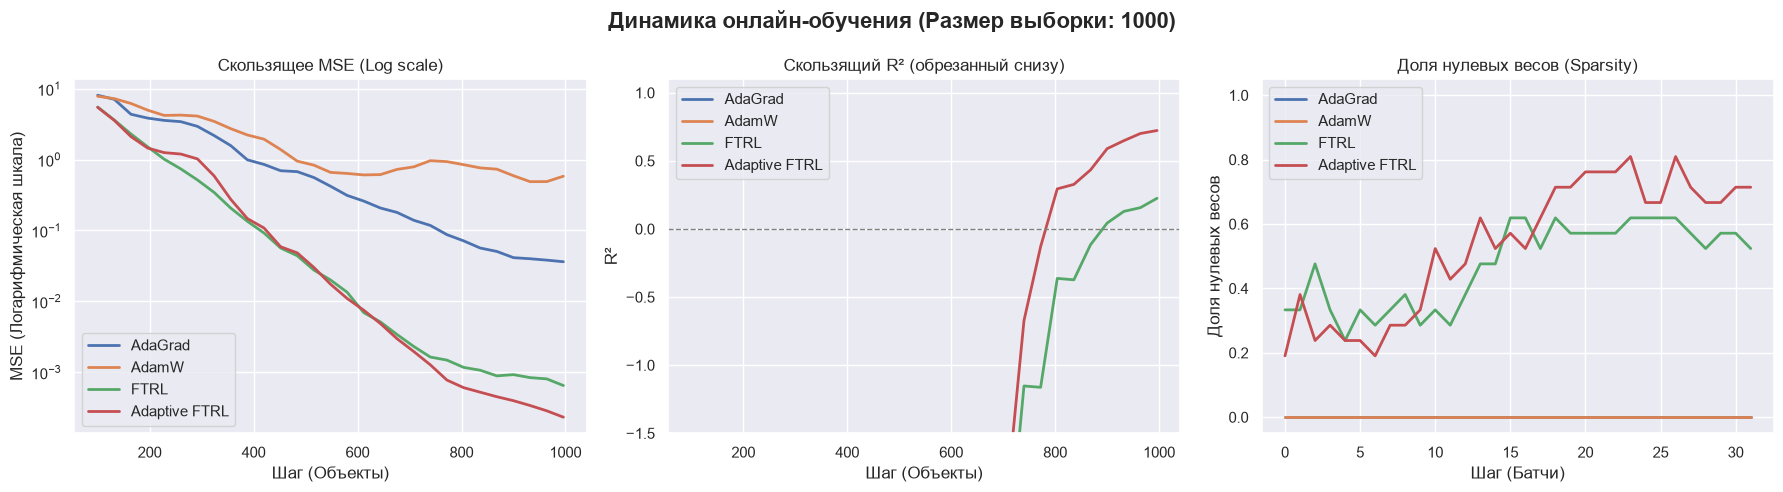


[Запуск потока для выборки: 3000 объектов...]

~~~~~~~~ФИНАЛЬНЫЕ МЕТРИКИ ДЛЯ РАЗМЕРА 3000~~~~~~~~~~~~
Алгоритм        | MSE        | MAE        | R^2_(Последнее окно)
-----------------------------------------------------------------
AdaGrad         | 0.0029     | 0.0347     | -2.2130   
AdamW           | 0.0075     | 0.0647     | -7.2681   
FTRL            | 0.0002     | 0.0113     | 0.7676    
Adaptive FTRL   | 0.0002     | 0.0114     | 0.7567    


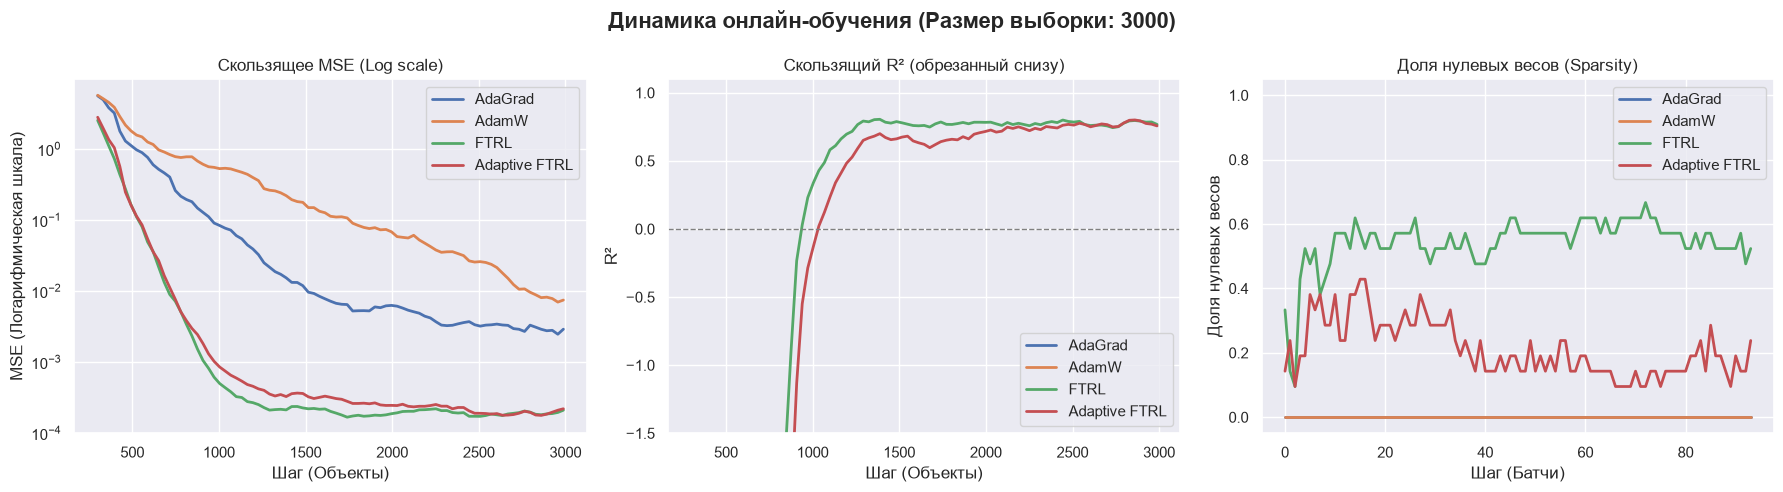


[Запуск потока для выборки: 5000 объектов...]

~~~~~~~~ФИНАЛЬНЫЕ МЕТРИКИ ДЛЯ РАЗМЕРА 5000~~~~~~~~~~~~
Алгоритм        | MSE        | MAE        | R^2_(Последнее окно)
-----------------------------------------------------------------
AdaGrad         | 0.0016     | 0.0286     | -0.8734   
AdamW           | 0.0003     | 0.0126     | 0.6664    
FTRL            | 0.0001     | 0.0092     | 0.8247    
Adaptive FTRL   | 0.0002     | 0.0096     | 0.8120    


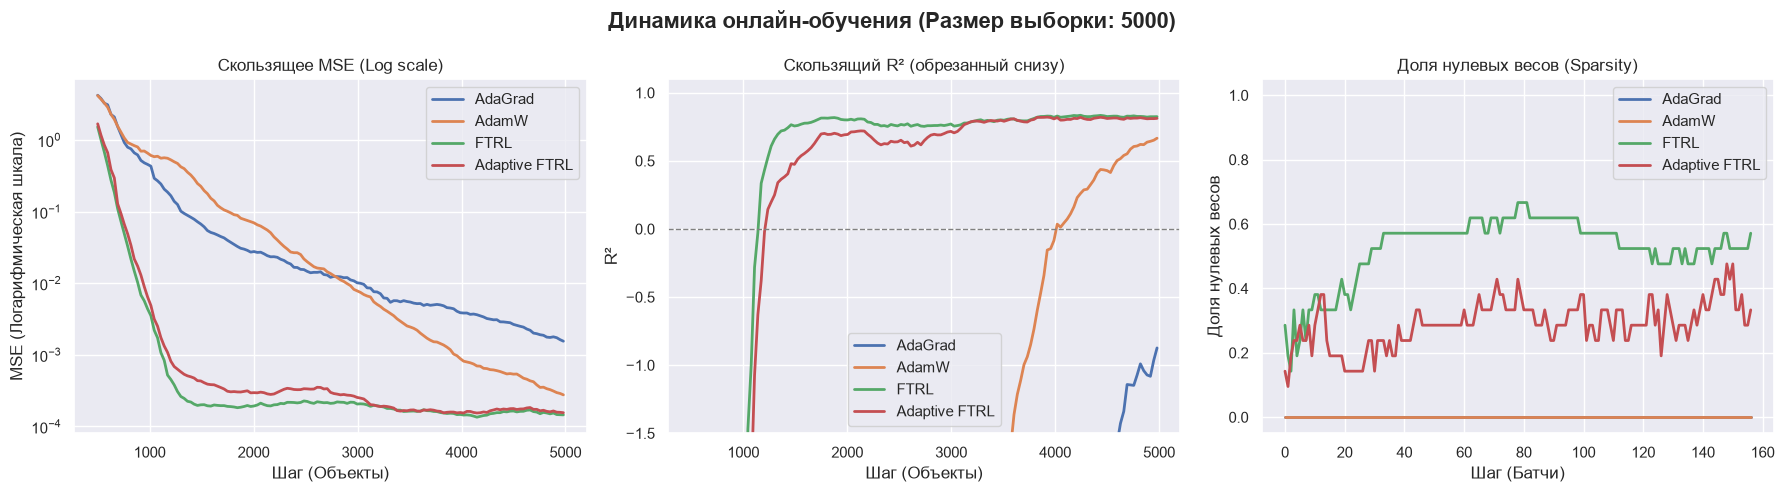


[Запуск потока для выборки: all объектов...]

~~~~~~~~ФИНАЛЬНЫЕ МЕТРИКИ ДЛЯ РАЗМЕРА all~~~~~~~~~~~~
Алгоритм        | MSE        | MAE        | R^2_(Последнее окно)
-----------------------------------------------------------------
AdaGrad         | 0.0004     | 0.0144     | 0.4255    
AdamW           | 0.0004     | 0.0148     | 0.4230    
FTRL            | 0.0002     | 0.0092     | 0.7489    
Adaptive FTRL   | 0.0002     | 0.0092     | 0.7475    


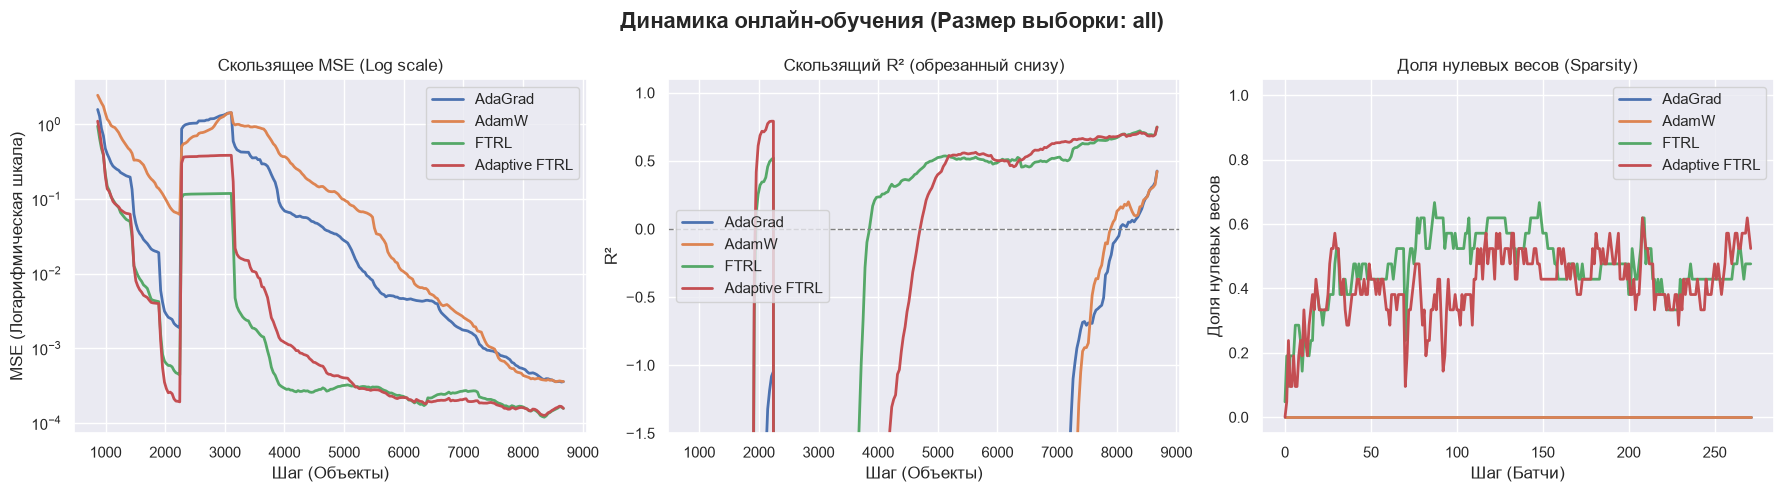

In [12]:
sns.set_theme(style="darkgrid")

sizes = [1000, 3000, 5000, "all"]
fit_intercept = True

for size in sizes:
    print(f"\n[Запуск потока для выборки: {size} объектов...]")
    X, y = load_data(size)
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0) + 1e-9
    X = (X - X_mean) / X_std
    num_samples, input_dim = X.shape
    
    models = {
        "AdaGrad": OnlineAdaGrad(input_dim=input_dim, **best_params["AdaGrad"], fit_intercept=fit_intercept),
        "AdamW": OnlineAdamW(input_dim=input_dim, **best_params["AdamW"], fit_intercept=fit_intercept),
        "FTRL": FTRL(input_dim=input_dim, **best_params["FTRL"], fit_intercept=fit_intercept),
        "Adaptive FTRL": AdaptiveFTRL(input_dim=input_dim, **best_params["AdaptiveFTRL"], fit_intercept=fit_intercept)
    }
    
    history = {name: {"loss": [], "sparsity": [], "y_true": [], "y_pred": []} for name in models.keys()}
    
    for t in range(0, num_samples, batch_size):
        x_batch = X[t : t + batch_size]
        y_batch = y[t : t + batch_size]
        if x_batch.shape[0] == 0:
            continue
            
        for name, model in models.items():
            y_pred, loss_val = model.update(x_batch, y_batch)
            
            history[name]["loss"].append(loss_val)
            history[name]["sparsity"].append(np.sum(model.w == 0.0) / len(model.w))
            history[name]["y_true"].extend(y_batch)
            history[name]["y_pred"].extend(y_pred.flatten())

    window_objects = max(50, num_samples // 10)
    if window_objects >= num_samples:
        window_objects = num_samples // 2

    step = max(1, batch_size) 
    rolling_metrics = {name: {"steps": [], "mse": [], "r2": []} for name in models.keys()}

    # РАСЧЕТ МЕТРИК В СКОЛЬЗЯЩЕМ ОКНЕ
    for name in models.keys():
        y_true_arr = np.array(history[name]["y_true"])
        y_pred_arr = np.array(history[name]["y_pred"])
        n_total = len(y_true_arr)
        
        for i in range(window_objects, n_total, step):
            yt_win = y_true_arr[i - window_objects : i]
            yp_win = y_pred_arr[i - window_objects : i]
            
            mse_win = np.mean((yt_win - yp_win) ** 2)
            
            ss_res = np.sum((yt_win - yp_win) ** 2)
            ss_tot = np.sum((yt_win - np.mean(yt_win)) ** 2)
            r2_win = 1.0 - (ss_res / (ss_tot + 1e-9))
            
            rolling_metrics[name]["steps"].append(i)
            rolling_metrics[name]["mse"].append(mse_win)
            rolling_metrics[name]["r2"].append(r2_win)

    print(f"\n~~~~~~~~ФИНАЛЬНЫЕ МЕТРИКИ ДЛЯ РАЗМЕРА {size}~~~~~~~~~~~~")
    print(f"{'Алгоритм':<15} | {'MSE':<10} | {'MAE':<10} | {'R^2_(Последнее окно)':<10}")
    print("-" * 65)
    for name in models.keys():
        last_mse = rolling_metrics[name]["mse"][-1] if rolling_metrics[name]["mse"] else np.nan
        last_r2 = rolling_metrics[name]["r2"][-1] if rolling_metrics[name]["r2"] else np.nan
        y_true_arr_curr = np.array(history[name]["y_true"])
        y_pred_arr_curr = np.array(history[name]["y_pred"])
        last_mae = np.mean(np.abs(y_true_arr_curr[-window_objects:] - y_pred_arr_curr[-window_objects:]))
        
        print(f"{name:<15} | {last_mse:<10.4f} | {last_mae:<10.4f} | {last_r2:<10.4f}")
    
    # ~~~~~~~~~  ПОСТРОЕНИЕ ГРАФИКОВ ~~~~~~~~~~~
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Динамика онлайн-обучения (Размер выборки: {size})", fontsize=16, fontweight='bold')

    data_list = []
    for name in models.keys():
        steps = rolling_metrics[name]["steps"]
        mses = rolling_metrics[name]["mse"]
        r2s = rolling_metrics[name]["r2"]
        for s, m, r in zip(steps, mses, r2s):
            data_list.append({"Алгоритм": name, "Шаг (Объекты)": s, "MSE": m, "R2": r})
    df_metrics = pd.DataFrame(data_list)

    sparsity_list = []
    for name in models.keys():
        sparsities = history[name]["sparsity"]
        for idx, sp in enumerate(sparsities):
            sparsity_list.append({"Алгоритм": name, "Шаг (Батчи)": idx, "Разреженность": sp})
    df_sparsity = pd.DataFrame(sparsity_list)

    if not df_metrics.empty:
        sns.lineplot(ax=axes[0], data=df_metrics, x="Шаг (Объекты)", y="MSE", hue="Алгоритм", linewidth=2)
        axes[0].set_yscale("log")
        axes[0].set_title("Скользящее MSE (Log scale)")
        axes[0].set_ylabel("MSE (Логарифмическая шкала)")

        sns.lineplot(ax=axes[1], data=df_metrics, x="Шаг (Объекты)", y="R2", hue="Алгоритм", linewidth=2)
        axes[1].set_ylim(-1.5, 1.1)  # Обрезаем бесконечные падения плохих моделей
        axes[1].set_title("Скользящий R² (обрезанный снизу)")
        axes[1].set_ylabel("R²")
        axes[1].axhline(y=0, color='grey', linestyle='--', linewidth=1)

    if not df_sparsity.empty:
        sns.lineplot(ax=axes[2], data=df_sparsity, x="Шаг (Батчи)", y="Разреженность", hue="Алгоритм", linewidth=2)
        axes[2].set_title("Доля нулевых весов (Sparsity)")
        axes[2].set_ylabel("Доля нулевых весов")
        axes[2].set_ylim(-0.05, 1.05)

    for ax in axes:
        ax.legend(loc="best")
        
    plt.tight_layout()
    plt.show()

# ВЫВОДЫ
FTRL и Adaptive FTRL дают хороший результат (относительно других моделей) практически со старта (уже на 1000 объектах R^2 равен 0.72+), что во многом связано с агрессивной L1-регуляризацией. 
Из графиках следует, что FTRL держит около 40–60% весов нулевыми. Модели получаются легкими, не переобучаются на шуме и моментально подстраиваются под реальные сигналы.
---
AdaGrad и AdamW слишком сложны для онлайн-обучения, поскольку им нужно критически много времени на "прогрес.
AdamW на малых выборках выдает огромные ошибки (R^2 = -694), имея возможность конкурировать с остальными моделями только ближе к 5000 объектам. У этих алгоритмов нет механизма жесткого зануления весов (Sparsity всегда на нуле), из-за чего они копят в памяти старые "знания" и медленно реагируют на изменения.
---
На графиках полной выборки (all) около 2200-го шага метрики всех моделей резко полетели вниз. 
FTRL-модели среагировали следующим образом: они временно снизили долю нулевых весов (активировали нужные коэффициенты), быстро переобучились и вернулись к высокому R^2 (~0.75). AdaGrad и AdamW тоже адаптировались, но восстанавливались дольше и лишь до 0.42.
---
- (заметка на полях) Изначально при батчевом обновлении шаг у Adaptive FTRL затухал слишком быстро, из-за чего модель застревала с плохими метриками, что решилось настройкой alpha = 1.0 и beta = 1.0. Теперь адаптивный вариант сравним с классическим FTRL, при этом на 3000–5000 объектов он показывает даже более плавную и стабильную сходимость.